In [12]:
class Value:
    def __init__(self, data, _children = (), _op= '', label = ''):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self.grad = 0
        self.label = label
    
    def __repr__(self):
        return f"Value(data = {self.data})"
    
    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
        return out
    
    def __mul__(self, other):
        out = Value(self.data*other.data, (self, other), '*')
        return out
    



In [ ]:
a = Value(data = 2.0); a.label = 'a'
b = Value(data = -3.0); b.label = 'b'
c= Value(data = 10.0); c.label = 'c'
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label = 'f');
L = d*f; L.label = 'L'

In [ ]:
from graphviz import Digraph

#Digraph library, used for representing neural nets.
#First function is a simple graph building function, the second one uses nodes, as data-points and 

def trace(root):
    """Walk the graph backward from `root`, collecting every node and edge."""
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges


def draw_dot(root, format='svg', rankdir='LR'):
    """
    Render the computation graph rooted at `root`.

    format:  'svg' | 'png' | ...   (svg is crisp in notebooks)
    rankdir: 'LR' (left-to-right) | 'TB' (top-to-bottom)
    """
    assert rankdir in ('LR', 'TB')
    nodes, edges = trace(root)

    dot = Digraph(
        format=format,
        graph_attr={'rankdir': rankdir},
    )

    for n in nodes:
        # each Value gets a rectangular "record" node showing label | data | grad
        dot.node(
            name=str(id(n)),
            label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad),
            shape='record',
        )
        # if this Value was produced by an operation, add an op node and wire it in
        if n._op:
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))

    for n1, n2 in edges:
        # connect n1 to the op node that produced n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

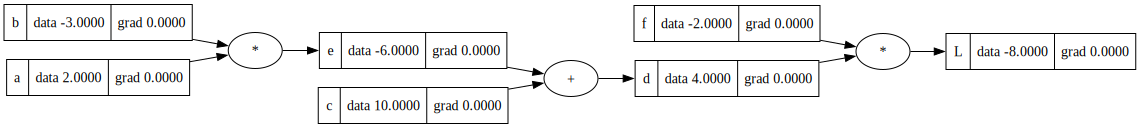

In [21]:
draw_dot(L)

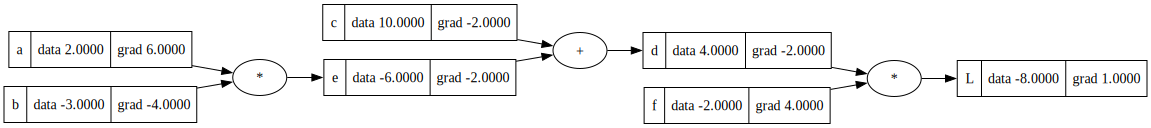

In [ ]:
h = 0.0001

a = Value(data = 2.0); a.label = 'a'
b = Value(data = -3.0); b.label = 'b'
c= Value(data = 10.0); c.label = 'c'
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label = 'f');
L = d*f; L.label = 'L'
L1 = L.data


a = Value(data = 2.0); a.label = 'a'
b = Value(data = -3.0); b.label = 'b'
c= Value(data = 10.0) ; c.label = 'c'
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label = 'f');
L = d*f; L.label = 'L'
L2 = L.data

L.grad = 1
a.grad = 6
d.grad = -2
f.grad = 4
b.grad = -4
c.grad = -2
e.grad = -2

draw_dot(L)